In [7]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    f1_score,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [8]:
train_df = pd.read_excel("../data/processed/disaster_train.xlsx")
test_df  = pd.read_excel("../data/processed/disaster_test.xlsx")

print("Train:", train_df.shape)
print("Test :", test_df.shape)
print()
print("Columns:", train_df.columns.tolist())
print()
print("Train target distribution:")
print(train_df["target"].value_counts())

Train: (13979, 28)
Test : (3495, 28)

Columns: ['Country', 'Subregion', 'Region', 'Associated Types', 'OFDA/BHA Response', 'Appeal', 'Declaration', "AID Contribution ('000 US$)", 'Magnitude', 'Magnitude Scale', 'Start Year', 'Start Month', 'Start Day', 'End Year', 'End Month', 'End Day', 'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected', "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)", "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)", "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)", 'target']

Train target distribution:
target
Flood           4946
Storm           4042
Earthquake      1321
Epidemic        1298
Landslide        734
Drought          643
Extreme Temp     584
Wildfire         411
Name: count, dtype: int64


In [ ]:
# ── Scenario C: post-event impact + response feature engineering ──

IMPACT_NUM_COLS = [
    'Total Deaths', 'No. Injured', 'No. Affected', 'No. Homeless', 'Total Affected',
    "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)",
    "Reconstruction Costs ('000 US$)", "Reconstruction Costs, Adjusted ('000 US$)",
    "Insured Damage ('000 US$)", "Insured Damage, Adjusted ('000 US$)",
    "AID Contribution ('000 US$)",
]

RESPONSE_FLAG_COLS = ['Appeal', 'OFDA/BHA Response', 'Declaration']


def _safe_name(col):
    return (
        col.replace("'000 US$", "usd")
           .replace(",", "")
           .replace(".", "")
           .replace("(", "").replace(")", "")
           .replace("/", "_")
           .strip()
           .replace(" ", "_")
           .lower()
    )


def fit_impact_response(t, params):
    """Add impact/response feature engineering. Fit stats (medians, categories) on TRAIN only."""
    t = t.copy()
    impact_medians = {}

    for col in IMPACT_NUM_COLS:
        if col not in t.columns:
            continue
        safe = _safe_name(col)
        t[col] = pd.to_numeric(t[col], errors="coerce")

        # missingness as signal (impact fields are often null when an aspect wasn't tracked/applicable)
        t[f"{safe}_missing"] = t[col].isna().astype(int)

        median_val = t[col].median()
        impact_medians[col] = median_val
        t[col] = t[col].fillna(median_val).clip(lower=0)

        # heavy right skew -> log transform
        t[f"{safe}_log"] = np.log1p(t[col])

    response_cats = {}
    for col in RESPONSE_FLAG_COLS:
        if col not in t.columns:
            continue
        t[col] = t[col].fillna("Unknown").astype(str).str.strip()
        cats = sorted(t[col].unique().tolist())
        response_cats[col] = cats
        safe_col = _safe_name(col)
        for cat in cats:
            safe_cat = _safe_name(cat)
            t[f"{safe_col}_{safe_cat}"] = (t[col] == cat).astype(int)

    params["impact_medians"] = impact_medians
    params["response_cats"] = response_cats
    return t, params


def transform_impact_response(t, params):
    """Apply TRAIN-fitted impact/response stats to any dataframe."""
    t = t.copy()

    for col in IMPACT_NUM_COLS:
        if col not in t.columns:
            continue
        safe = _safe_name(col)
        t[col] = pd.to_numeric(t[col], errors="coerce")
        t[f"{safe}_missing"] = t[col].isna().astype(int)
        median_val = params["impact_medians"].get(col, 0)
        t[col] = t[col].fillna(median_val).clip(lower=0)
        t[f"{safe}_log"] = np.log1p(t[col])

    for col, cats in params.get("response_cats", {}).items():
        if col not in t.columns:
            continue
        t[col] = t[col].fillna("Unknown").astype(str).str.strip()
        safe_col = _safe_name(col)
        for cat in cats:
            safe_cat = _safe_name(cat)
            t[f"{safe_col}_{safe_cat}"] = (t[col] == cat).astype(int)

    return t


def fit_preprocess_C(train):
    """Full Scenario C fit: base preprocessing + impact/response features."""
    t, params = fit_preprocess(train)          
    t, params = fit_impact_response(t, params)
    return t, params


def transform_preprocess_C(data, params):
    """Full Scenario C transform: base preprocessing + impact/response features."""
    t = transform_preprocess(data, params)
    t = transform_impact_response(t, params)
    return t


print("Scenario C preprocessing functions defined")

Scenario C preprocessing functions defined


In [14]:
train_processed, params = fit_preprocess_C(train_df)
test_processed = transform_preprocess_C(test_df, params)

print("Train processed:", train_processed.shape)
print("Test processed :", test_processed.shape)

Train processed: (13979, 96)
Test processed : (3495, 96)


In [16]:
# feature list
feature_cols = [
    "Start Year",
    "start_month_sin", "start_month_cos",
    "start_day_sin", "start_day_cos",
    "event_duration_log",
    "magnitude_missing", "magnitude_scaled",
    "country_freq",
]
feature_cols += [c for c in train_processed.columns if c.startswith("mag_scale_")]
feature_cols += [c for c in train_processed.columns if c.startswith("region_")]
feature_cols += [c for c in train_processed.columns if c.startswith("subregion_")]

if "origin_freq" in train_processed.columns:
    feature_cols.append("origin_freq")
if "assoc_freq" in train_processed.columns:
    feature_cols.append("assoc_freq")

feature_cols = [c for c in feature_cols if c in train_processed.columns]
print(f"Total features: {len(feature_cols)}")

# target from original split
le = LabelEncoder()
y_train = le.fit_transform(train_df["target"])
y_test  = le.transform(test_df["target"])

# feature matrices
X_train = train_processed[feature_cols].copy()
X_test  = test_processed[feature_cols].copy()

for c in feature_cols:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[feature_cols]

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")
print(f"y_train: {y_train.shape} | y_test: {y_test.shape}")
print("Classes:", list(le.classes_))

Total features: 38
X_train: (13979, 38)
X_test : (3495, 38)
y_train: (13979,) | y_test: (3495,)
Classes: ['Drought', 'Earthquake', 'Epidemic', 'Extreme Temp', 'Flood', 'Landslide', 'Storm', 'Wildfire']


In [17]:
# ── post-event impact + response features (Scenario C) ──
feature_cols += [c for c in train_processed.columns if c.endswith("_missing") and c not in feature_cols]
feature_cols += [c for c in train_processed.columns if c.endswith("_log") and c not in feature_cols and c != "event_duration_log"]

# response one-hots: appeal_*, ofda_bha_response_*, declaration_*
response_prefixes = ("appeal_", "ofda_bha_response_", "declaration_")
feature_cols += [
    c for c in train_processed.columns
    if c.startswith(response_prefixes) and c not in feature_cols
]

feature_cols = [c for c in feature_cols if c in train_processed.columns]
print(f"Total features (with post-event): {len(feature_cols)}")

Total features (with post-event): 68


In [36]:
post_event_added = [c for c in feature_cols if any(k in c for k in
    ["deaths","injured","affected","homeless","damage","reconstruction","insured","aid","appeal","ofda","declaration"])]
print(f"Post-event features included ({len(post_event_added)}):")
print(post_event_added)

Post-event features included (30):
['total_deaths_missing', 'no_injured_missing', 'no_affected_missing', 'no_homeless_missing', 'total_affected_missing', 'total_damage_usd_missing', 'total_damage_adjusted_usd_missing', 'reconstruction_costs_usd_missing', 'reconstruction_costs_adjusted_usd_missing', 'insured_damage_usd_missing', 'insured_damage_adjusted_usd_missing', 'aid_contribution_usd_missing', 'total_deaths_log', 'no_injured_log', 'no_affected_log', 'no_homeless_log', 'total_affected_log', 'total_damage_usd_log', 'total_damage_adjusted_usd_log', 'reconstruction_costs_usd_log', 'reconstruction_costs_adjusted_usd_log', 'insured_damage_usd_log', 'insured_damage_adjusted_usd_log', 'aid_contribution_usd_log', 'appeal_no', 'appeal_yes', 'ofda_bha_response_no', 'ofda_bha_response_yes', 'declaration_no', 'declaration_yes']


In [35]:
# rebuild feature matrices now that feature_cols includes the post-event columns
X_train = train_processed[feature_cols].copy()
X_test  = test_processed[feature_cols].copy()

for c in feature_cols:
    if c not in X_test.columns:
        X_test[c] = 0
X_test = X_test[feature_cols]

print(f"X_train: {X_train.shape}")
print(f"X_test : {X_test.shape}")

X_train: (13979, 68)
X_test : (3495, 68)


In [37]:
class_names = list(le.classes_)


def evaluate_model(model, X_tr, y_tr, X_te, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    acc = accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average="macro")
    weighted_f1 = f1_score(y_te, y_pred, average="weighted")

    print("=" * 65)
    print(name)
    print("=" * 65)
    print(f"Accuracy    : {acc:.4f}")
    print(f"Macro-F1    : {macro_f1:.4f}")
    print(f"Weighted-F1 : {weighted_f1:.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=class_names, digits=3))

    return {
        "Model": name,
        "Accuracy": acc,
        "Macro-F1": macro_f1,
        "Weighted-F1": weighted_f1,
        "y_pred": y_pred,
        "model": model,
    }


models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=3, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression( max_iter=1000, random_state=42 ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42, n_jobs=-1
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, verbosity=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=100, random_state=42, n_jobs=-1, eval_metric="mlogloss"
    ),
}

print("Models:", list(models.keys()))

Models: ['Decision Tree', 'SVM', 'Logistic Regression', 'Random Forest', 'LightGBM', 'XGBoost']


In [38]:
results = []
for name, model in models.items():
    res = evaluate_model(model, X_train, y_train, X_test, y_test, name)
    results.append(res)

Decision Tree
Accuracy    : 0.8512
Macro-F1    : 0.5272
Weighted-F1 : 0.8029

              precision    recall  f1-score   support

     Drought      0.916     0.475     0.626       160
  Earthquake      1.000     1.000     1.000       330
    Epidemic      0.495     1.000     0.662       324
Extreme Temp      0.000     0.000     0.000       146
       Flood      0.871     0.998     0.930      1237
   Landslide      0.000     0.000     0.000       184
       Storm      1.000     1.000     1.000      1011
    Wildfire      0.000     0.000     0.000       103

    accuracy                          0.851      3495
   macro avg      0.535     0.559     0.527      3495
weighted avg      0.780     0.851     0.803      3495

SVM
Accuracy    : 0.3539
Macro-F1    : 0.0654
Weighted-F1 : 0.1850

              precision    recall  f1-score   support

     Drought      0.000     0.000     0.000       160
  Earthquake      0.000     0.000     0.000       330
    Epidemic      0.000     0.000     0.

In [41]:
from sklearn.metrics import precision_score

summary = pd.DataFrame(
    [
        {
            "Model": r["Model"],
            "Accuracy": r["Accuracy"],
            "Precision Macro": precision_score(y_test, r["y_pred"], average="macro", zero_division=0),
            "Precision Weighted": precision_score(y_test, r["y_pred"], average="weighted", zero_division=0),
            "Macro-F1": r["Macro-F1"],
            "Weighted-F1": r["Weighted-F1"],
        }
        for r in results
    ]
).sort_values("Macro-F1", ascending=False).reset_index(drop=True)

print(summary.round(4).to_string(index=False))

              Model  Accuracy  Precision Macro  Precision Weighted  Macro-F1  Weighted-F1
            XGBoost    0.9691           0.9483              0.9680    0.9314       0.9679
           LightGBM    0.9702           0.9575              0.9696    0.9286       0.9682
      Random Forest    0.9645           0.9474              0.9631    0.9085       0.9609
Logistic Regression    0.9325           0.8785              0.9262    0.8331       0.9254
      Decision Tree    0.8512           0.5352              0.7799    0.5272       0.8029
                SVM    0.3539           0.0442              0.1253    0.0654       0.1850


Best model: XGBoost  (Macro-F1 = 0.9314)

Top 15 Feature Importances:
mag_scale_Kph                          0.2171
mag_scale_Moment_Magnitude             0.2146
mag_scale_C                            0.1783
mag_scale_Vaccinated                   0.1775
mag_scale_Unknown                      0.0674
mag_scale_Km2                          0.0669
region_Africa                          0.0143
subregion_Northern America             0.0074
no_homeless_missing                    0.0048
total_deaths_missing                   0.0045
event_duration_log                     0.0042
start_day_cos                          0.0036
subregion_Australia and New Zealand    0.0034
total_affected_missing                 0.0028
magnitude_missing                      0.0025


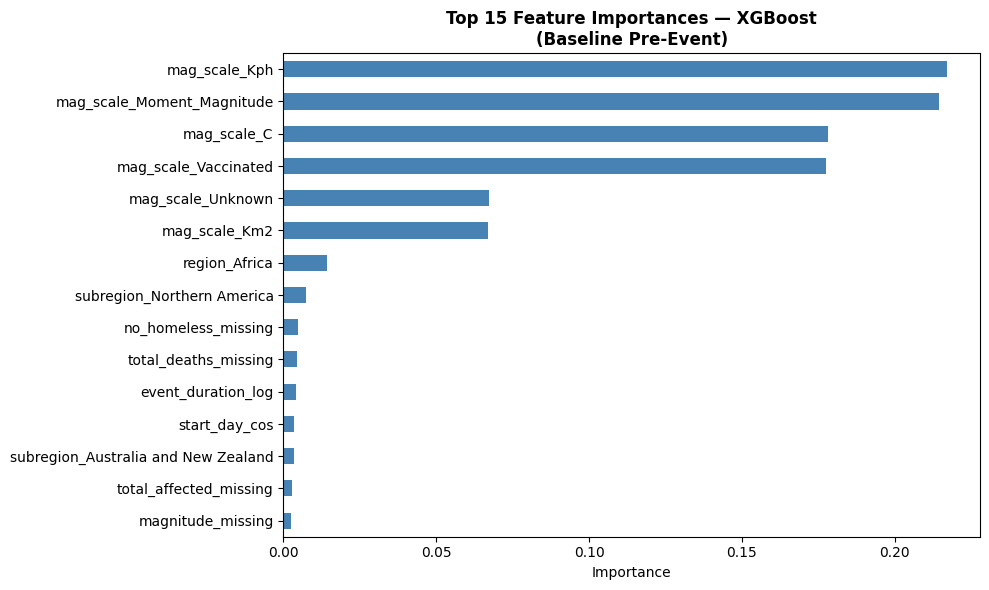

In [42]:
best = max(results, key=lambda x: x["Macro-F1"])
best_model = best["model"]
best_name  = best["Model"]

print(f"Best model: {best_name}  (Macro-F1 = {best['Macro-F1']:.4f})")

if hasattr(best_model, "feature_importances_"):
    imp = pd.Series(best_model.feature_importances_, index=feature_cols)
    imp = imp.sort_values(ascending=False)

    print("\nTop 15 Feature Importances:")
    print(imp.head(15).round(4).to_string())

    plt.figure(figsize=(10, 6))
    imp.head(15).sort_values().plot(kind="barh", color="steelblue")
    plt.title(f"Top 15 Feature Importances — {best_name}\n(Baseline Pre-Event)", fontweight="bold")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print(f"{best_name} has no feature_importances_.")

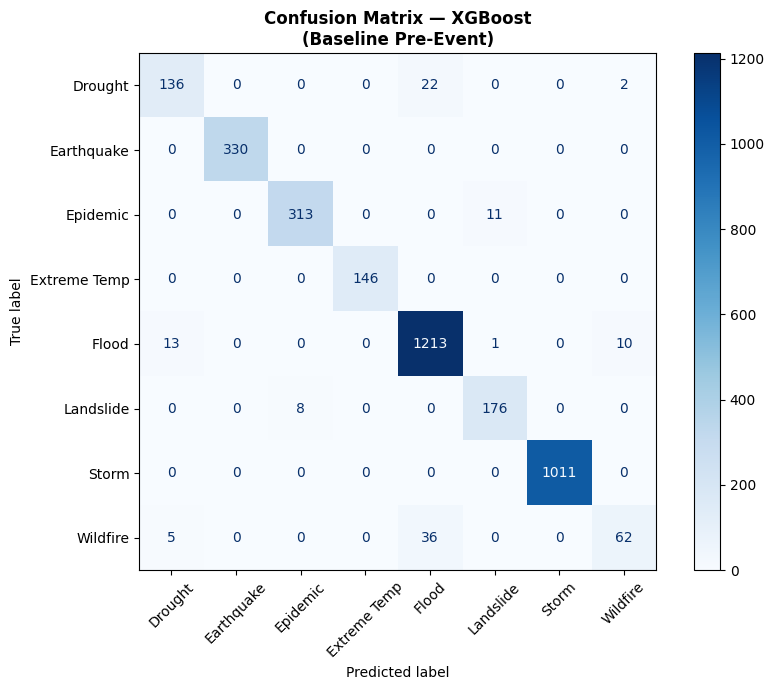

In [48]:
cm = confusion_matrix(y_test, best["y_pred"])

fig, ax = plt.subplots(figsize=(9, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
ax.set_title(
    f"Confusion Matrix — {best_name}\n(Baseline Pre-Event)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

In [43]:
X_train.to_csv("../data/processed/X_train_processed.csv", index=False)
X_test.to_csv("../data/processed/X_test_processed.csv", index=False)

In [46]:
pd.DataFrame(y_train, columns=["target"]).to_csv(
    "../data/processed/y_train_processed.csv", index=False
)
pd.DataFrame(y_test, columns=["target"]).to_csv(
    "../data/processed/y_test_processed.csv", index=False
)

In [47]:
import joblib

joblib.dump(le, "../data/processed/label_encoder.pkl")

['../data/processed/label_encoder.pkl']